In [124]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [125]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=56
)

y = np.where(y == 0, -1, 1) # should transform label before fitting data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=56
)

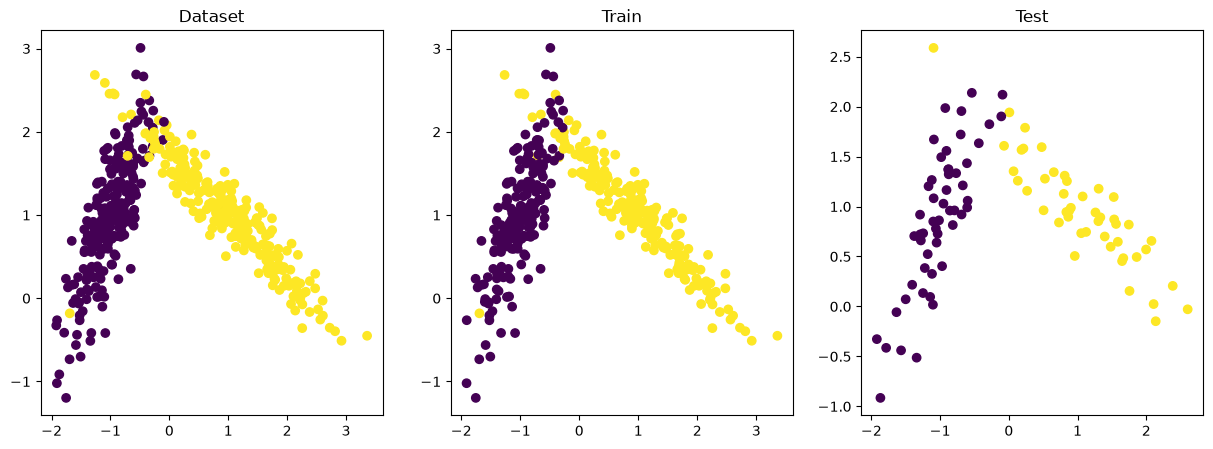

In [126]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].scatter(X[:, 0], X[:, 1], c=y)
axs[0].set_title("Dataset")

axs[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train)
axs[1].set_title("Train")

axs[2].scatter(X_test[:, 0], X_test[:, 1], c=y_test)
axs[2].set_title("Test");

In [127]:
class DecisionStump():
    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.polarity = 1

    def fit(self, X, y, sample_weights):
        
        min_error = 1e9 + 7
        for feature in range(X.shape[1]):
            feature_values = X[:, feature]
            uniques = np.unique(feature_values)
            thresholds = (uniques[1:] + uniques[:-1]) / 2

            for threshold in thresholds:

                # We dont know relation between class and threshold!
                for polarity in [-1, 1]:

                    predictions = np.ones(X.shape[0])
                    if polarity == 1:
                        predictions[feature_values >= threshold] = -1
                    else:
                        predictions[feature_values < threshold] = -1

                    misclassified = (predictions != y)
                    error = np.sum(sample_weights[misclassified])

                    if error < min_error:
                        self.feature_idx = feature
                        self.threshold = threshold
                        self.polarity = polarity
                        min_error = error

        return self

    def predict(self, X):
        predictions = np.ones(X.shape[0])
        feature_values = X[:, self.feature_idx]

        if self.polarity == 1:
            predictions[feature_values >= self.threshold] = -1
        else:
            predictions[feature_values < self.threshold] = -1

        return predictions

In [128]:
class AdaBoostClassifier():
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps = []
        self.alphas = []

    def fit(self, X, y):
        sample_weights = np.ones(X.shape[0]) / X.shape[0]

        for _ in range(self.n_estimators):
            stump = DecisionStump()
            stump.fit(X, y, sample_weights)

            predictions = stump.predict(X)
            error = np.sum(sample_weights[predictions != y])

            alpha = 0.5 * np.log((1 - error + 1e-10) / (error + 1e-10)) # Numerical stablity

            sample_weights *= np.exp(-alpha * y * predictions) # if (y == predictions) -> e^-alpha else e^alpha
            sample_weights = sample_weights / np.sum(sample_weights) # Normalizing

            self.stumps.append(stump)
            self.alphas.append(alpha)

    def predict(self, X):
        stump_predictions = np.array([alpha * stump.predict(X) for alpha, stump in zip(self.alphas, self.stumps)])
        y_pred = np.sum(stump_predictions, axis=0)
        return np.sign(y_pred)

In [129]:
from sklearn.metrics import f1_score

model = AdaBoostClassifier()
model.fit(X_train, y_train)
print(f"train: {f1_score(y_train, model.predict(X_train))}")
print(f"test: {f1_score(y_test, model.predict(X_test))}")

train: 0.9733656174334141
test: 0.9574468085106383


In [130]:
x1_grid = np.array([-1, 0, 1])
x2_grid = np.array([10, 20])

xx, yy = np.meshgrid(x1_grid, x2_grid)

print(xx)
print()
print(yy)

[[-1  0  1]
 [-1  0  1]]

[[10 10 10]
 [20 20 20]]


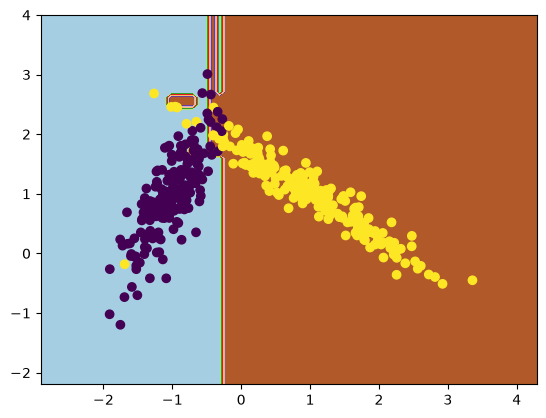

In [131]:
def plot_decision_boundary(X, y):
    min1, max1 = min(X[:, 0])-1, max(X[:, 0])+1
    min2, max2 = min(X[:, 1])-1, max(X[:, 1])+1

    x1_grid = np.arange(min1, max1, 0.1)
    x2_grid = np.arange(min2, max2, 0.1)

    xx, yy = np.meshgrid(x1_grid, x2_grid)
    r1, r2 = xx.reshape(-1, 1), yy.reshape(-1, 1)
    grid = np.concatenate([r1,r2], axis=1) # will be a matrix of all grid points

    y_hat = model.predict(grid)
    zz = y_hat.reshape(xx.shape)

    plt.contourf(xx, yy, zz, cmap="Paired")
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.show()

plot_decision_boundary(X_train, y_train)